У цьому ДЗ ми попрактикуємось моделювати часові ряди на даних з [Store Item Demand Forecasting Challenge](https://www.kaggle.com/competitions/demand-forecasting-kernels-only/overview). Ми будемо працювати лише з тренувальними даними цього змагання і задача у нас буде дещо змінена. Фокус буде на пошуці найкращої моделі, експериментах і використанні функціоналу `darts`.

Якщо якісно попрацювати в цьому завданні - це буде чудовий приклад проєкту для вашого портфоліо: "спрогнозував(-ла) поденні продажі на 1 міс для 50 товарів в 10 магазинах" звучить вражаюче! Але ми в рамках ДЗ для оптимізації часу сконцентруємось на моделюванні продажів одного товару в одному магазині.

**Задача**

Вам надано дані про продажі товарів у магазинах за 5 років. Хочемо навчитись передачати продажі в наступному місяці поденно кожного з 50 товарів у кожному з 10 магазинів. Відповідно будемо проводити експерименти, аби знайти найкращу модель для цього.

На відміну від змагання, ми будемо використовувати метрику МАРЕ (Mean Absolute Percentage Error) замість SMAPE (Symmetric Mean Absolute Percentage Error). Проте, ви також можете розрахувати SMAPE і подати свої результати через late submission на Kaggle.

1. Завантажуємо дані в Pandas.

  1. Завантажте дані з файлу `train.csv.zip` за допомогою бібліотеки Pandas.
  2. Перетворіть колонку `date` на формат `datetime`.
  3. Встановіть колонку `date` як індекс для датафрейму.
  4. Виведіть перші 10 рядків отриманого датафрейму та інформацію про датафрейм.

In [3]:
import pandas as pd
import datetime
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from darts import TimeSeries
from darts.utils.statistics import plot_acf, check_seasonality
from statsmodels.graphics.tsaplots import plot_predict
from statsmodels.graphics.tsaplots import plot_pacf
from darts.models import NaiveSeasonal, NaiveDrift, ARIMA, AutoARIMA, Prophet
from darts.metrics import mape
from darts.models import XGBModel, ExponentialSmoothing
from darts.dataprocessing.transformers import Scaler


In [4]:
df = pd.read_csv('time_series/train.csv')

In [5]:
df['date'] = df['date'].apply(lambda x: pd.to_datetime(x))

In [6]:
df.set_index('date', inplace=True)

In [7]:
df.head(10)

,store,item,sales
date,,,
2013-01-01,1,1,13
2013-01-02,1,1,11
2013-01-03,1,1,14
2013-01-04,1,1,13
2013-01-05,1,1,10
2013-01-06,1,1,12
2013-01-07,1,1,10
2013-01-08,1,1,9
2013-01-09,1,1,12


In [8]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 913000 entries, 2013-01-01 to 2017-12-31
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   store   913000 non-null  int64
 1   item    913000 non-null  int64
 2   sales   913000 non-null  int64
dtypes: int64(3)
memory usage: 27.9 MB


  2. Давайте трошки зрозуміємо дані. У нас 10 магазинів і 50 айтемів в кожному. Хочемо зрозуміти, чи відрізняється динаміка по кожному айтему в магазинах. Як би ви це візуалізували? Побудуйте 3 графіка, які вам допоможуть. Можна використати будь-який інструмент: matplotlib, seaborn, plotly.

  Напишіть висновок з побудованих вами візуалізацій.
  
    **Підказка**: я б спробувала вивести середнє значення і довірчий інтервал (який включає весь діапазон значень з різних магазинів) для динаміки кожного айтема, або принаймні для декількох айтемів, аби зрозуміти тенденцію.



Графік 1.

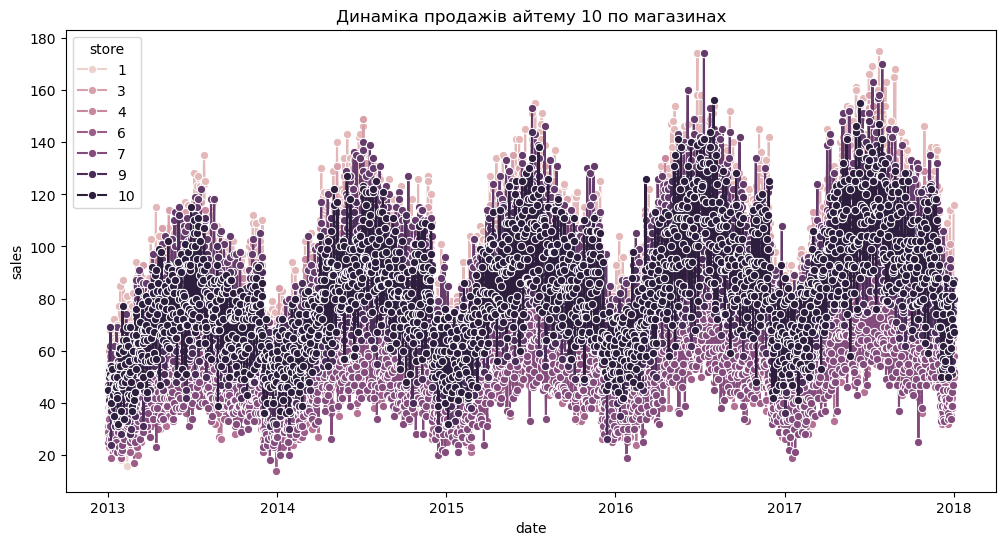

In [10]:
item = 10

df_item = df[df['item'] == item]

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_item,
    x='date',
    y='sales',
    hue='store',
    marker='o'
)

plt.title(f"Динаміка продажів айтему {item} по магазинах")
plt.show()

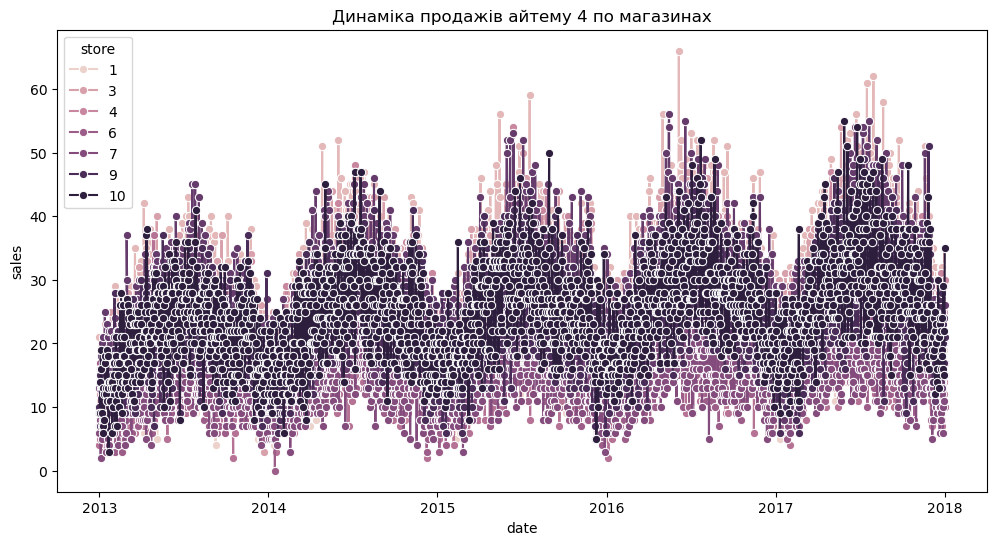

In [11]:
item = 4

df_item = df[df['item'] == item]

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_item,
    x='date',
    y='sales',
    hue='store',
    marker='o'
)

plt.title(f"Динаміка продажів айтему {item} по магазинах")
plt.show()

Графік 2

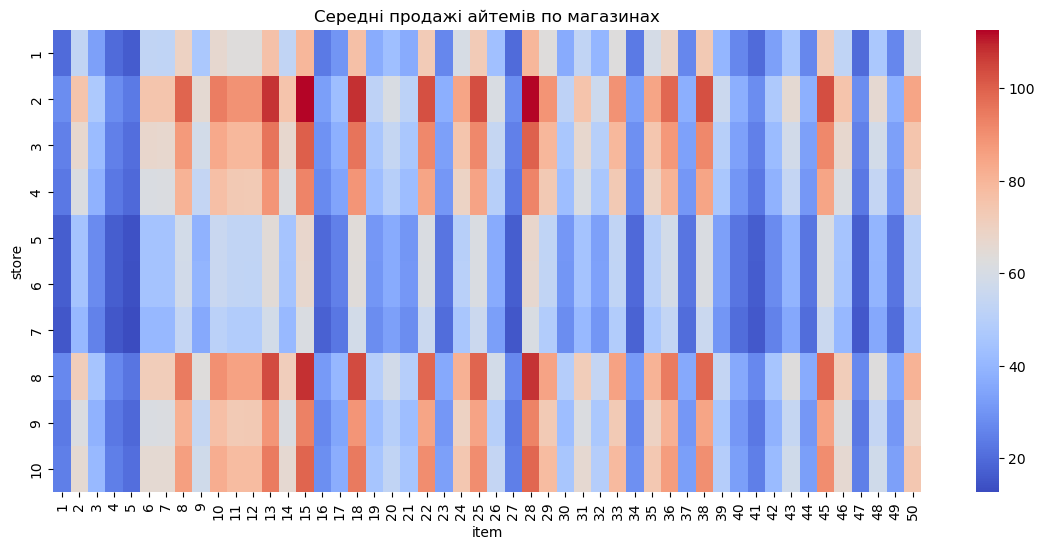

In [12]:
pivot = df.pivot_table(
    index='store',
    columns='item',
    values='sales',
    aggfunc='mean'
)

plt.figure(figsize=(14, 6))
sns.heatmap(pivot, cmap='coolwarm')

plt.title("Середні продажі айтемів по магазинах")
plt.show()

Графік 3

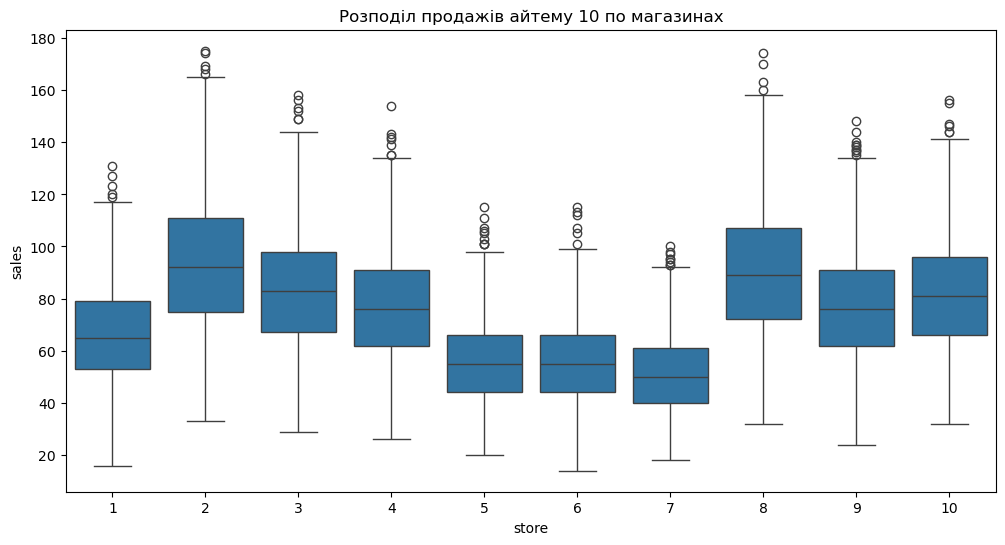

In [13]:
item = 10

df_item = df[df['item'] == item]

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_item,
    x='store',
    y='sales'
)

plt.title(f"Розподіл продажів айтему {item} по магазинах")
plt.show()

Висновки.
- Як бачимо з графіку 1, є сезонність, що відповідає за річний цикл продажів. Також є тренд на збільшення продажів кожного року.
- З графіку 2 - є значна різниця у розмірі продажів, як в залежності від айтема так і від магазину.
- Графік 3 - показує, що є розкид по продажі айтему по магазинах.

3. **Для початку проаналізуємо лише один ряд, а далі зможемо зациклити тренування моделей.**
  
  Виберіть підмножину даних, що відповідає продажам товару з `item == 1` у магазині з `store == 1`.

  Зробіть декомпозицію цього рядку за адитивною моделлю на тренд, сезонність і залишки з бібліотекою `statsmodels`.

  Зробіть висновки з отриманих візуалізацій. Чи щось би могло вам допомогти ліпше зрозуміти ці візуалізації? (з точки зору обробки даних)

In [14]:
df_sel = df[(df['item'] == 1) & (df['store'] == 1)]
df_additive = df_sel.copy(deep=True)

# рахуємо тренд згладжуючи ряд з річним вікном розміром 13
df_additive["trend"] = df_additive["sales"].rolling(window=16, center=True).mean()

# віднімаємо тренд з даних
df_additive["detrended"] = df_additive["sales"] - df_additive["trend"]

# рахуємо сезонну складову як середнє значення ряду пілся віднімання тренду
df_additive["month"] = df_additive.index.month
df_additive["seasonality"] = df_additive.groupby("month")["detrended"].transform("mean")

# обчислюємо залишок як все, що ми не змогли пояснити сезонністю
df_additive["resid"] = df_additive["detrended"] - df_additive["seasonality"]

# що у нас вийшло в результаті
df_additive.head(15)

,store,item,sales,trend,detrended,month,seasonality,resid
date,,,,,,,,
2013-01-01,1,1,13,NaN,NaN,1,-0.085034,NaN
2013-01-02,1,1,11,NaN,NaN,1,-0.085034,NaN
2013-01-03,1,1,14,NaN,NaN,1,-0.085034,NaN
2013-01-04,1,1,13,NaN,NaN,1,-0.085034,NaN
2013-01-05,1,1,10,NaN,NaN,1,-0.085034,NaN
2013-01-06,1,1,12,NaN,NaN,1,-0.085034,NaN
2013-01-07,1,1,10,NaN,NaN,1,-0.085034,NaN
2013-01-08,1,1,9,NaN,NaN,1,-0.085034,NaN
2013-01-09,1,1,12,10.1875,1.8125,1,-0.085034,1.897534


<Axes: xlabel='date'>

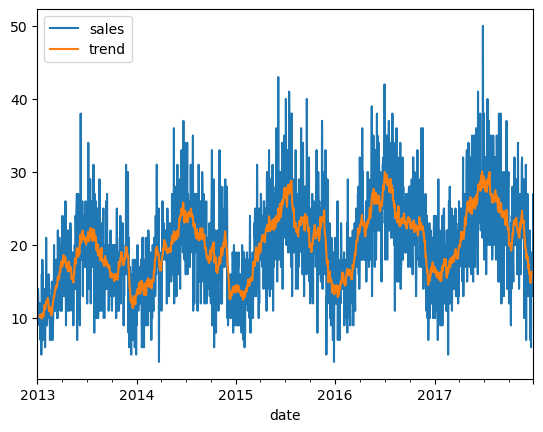

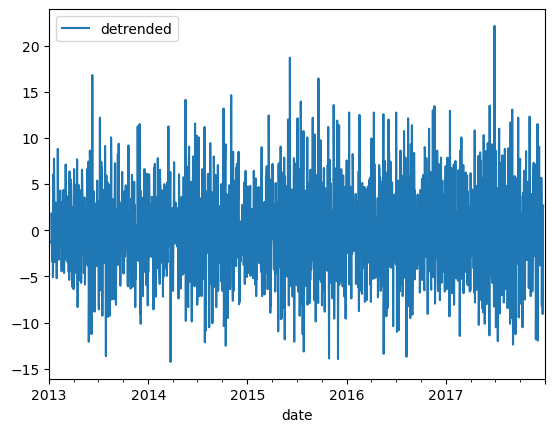

In [15]:
df_additive["trend_26"] = df_additive["sales"].rolling(window=26, center=True).mean()
df_additive[["sales", "trend"]].plot()
df_additive[["detrended"]].plot()

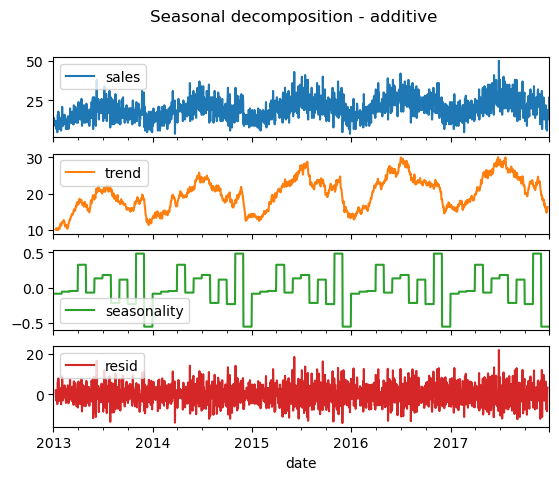

In [16]:
(
    df_additive
    .loc[:, ["sales", "trend", "seasonality", "resid"]]
    .plot(subplots=True, title="Seasonal decomposition - additive")
);

4. Зі створеної підможени даних в попередньому пункті створіть обʼєкт класу `TimeSeries` в `darts` лише для колонки `sales`.

In [17]:
series = TimeSeries.from_dataframe(
    df_additive,
    fill_missing_dates=True,
    freq='D',
    value_cols='sales'
)

5. Використовуючи метод `series.split_before` розбийте дані на тренування і валідацію так, аби валідація починалась з `2017-10-01` включно.

  Візуалізуйте на одному графіку тренувальну і валідаційну частину як було показано в лекції.

<Axes: xlabel='date'>

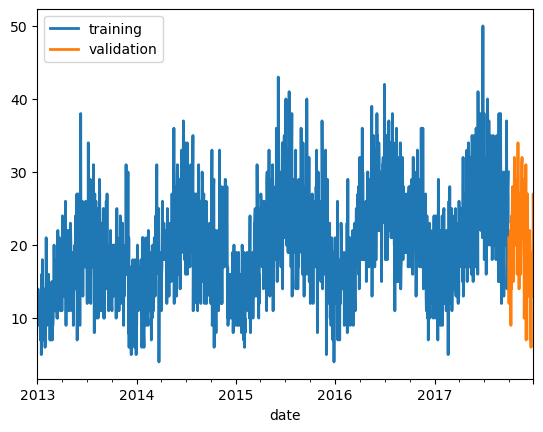

In [18]:
train, val = series.split_before(pd.Timestamp("2017-10-01"))
train.plot(label="training")
val.plot(label="validation")

6. Побудуйте часткову автокореляційну фукнцію для цього нашого ряду в `series`. Напишіть висновки - які лаги є важливими для прогнозування?

<Figure size 1000x500 with 0 Axes>

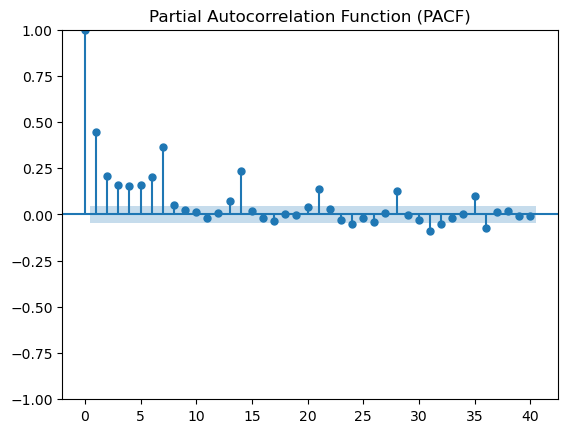

In [19]:
y = series.values().flatten()

plt.figure(figsize=(10, 5))
plot_pacf(y, lags=40)
plt.title("Partial Autocorrelation Function (PACF)")
plt.show()

Лаг 1 дуже сильний, є залежність від попереднього дня. Лаги 2-7, помірно значущі, лаг 7 - помітний пік, отже є тижнева сезонність.

7. Виявіть сезональність тренувального ряду використовуючи фукнкцію `check_seasonality` з `darts`.

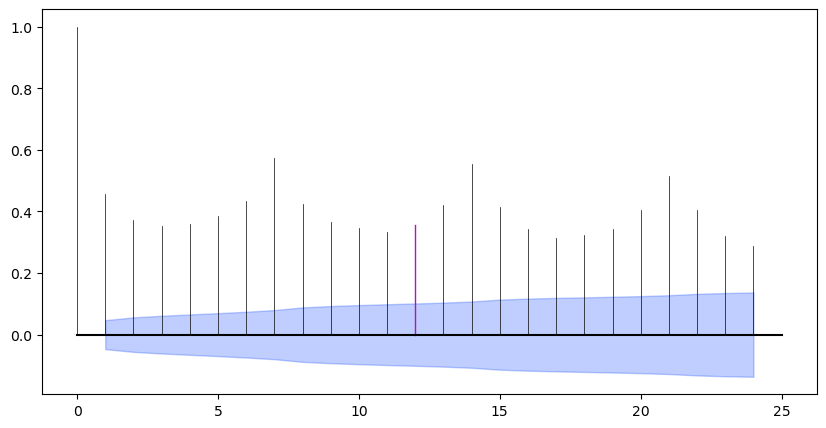

In [20]:
plot_acf(train, m=12, alpha=0.05, max_lag=24)

8. Побудуйте наївну модель NaiveSeasonal + NaieDrift для прогнозування даних. Кількість кроків для прогнозування визначіть зі свого аналізу в попередніх пунктах. Візуалізайте передбачення проти справжніх даних так, аби було видно якість передбачень. Зробіть висновок про модель. Вона точна?

  Якщо у вас є ідеї, як поліпшити якість передбачення саме наївними моделями - реалізуйте їх в цьому пункті :)

<Axes: xlabel='date'>

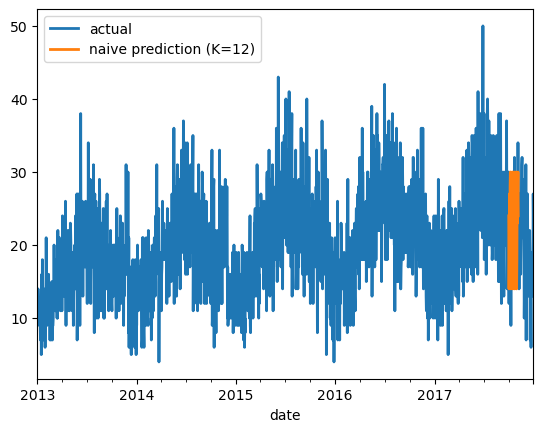

In [21]:
seasonal_model = NaiveSeasonal(K=7)
seasonal_model.fit(train)
seasonal_forecast = seasonal_model.predict(36)

series.plot(label="actual")
seasonal_forecast.plot(label="naive prediction (K=12)")

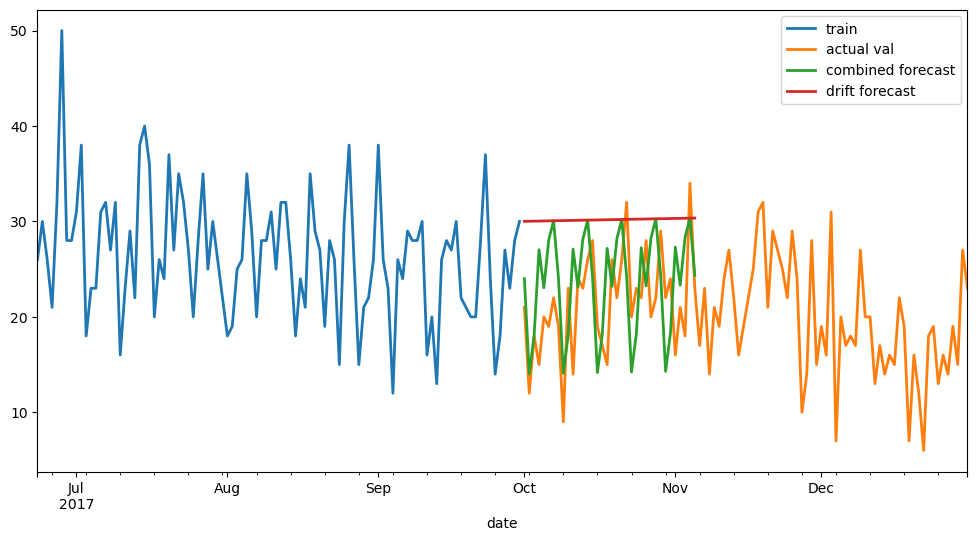

In [22]:
drift_model = NaiveDrift()
drift_model.fit(train)
drift_forecast = drift_model.predict(36)

combined_forecast = drift_forecast + seasonal_forecast - train.last_value()

plt.figure(figsize=(12, 6))
train[-100:].plot(label="train")
val.plot(label="actual val")
combined_forecast.plot(label="combined forecast")
drift_forecast.plot(label="drift forecast")
plt.show()

Drift model не враховує сезонності, combined forecast враховує сезонні коливання і краще відображає форму ряду, але переоцінює значення.

9. Обчисліть помилку прогнозу на валідації наївною моделлю з mape. Далі для всіх моделей необхідно обчислювати помилку прогнозу на валідації.

In [23]:
combined_forecast = drift_forecast + seasonal_forecast - val.last_value()
print(
    f"Mean absolute percentage error for the combined naive drift + seasonal: {mape(series, combined_forecast):.2f}%."
)

Mean absolute percentage error for the combined naive drift + seasonal: 50.75%.


10. Натренуйте XBGModel з `darts` для передбачення наших даних. Можна додавати всі додаткові ознаки, які вважаєте за потрібне, наприклад, ознаки з дати. Зробіть висновок про якість моделі.

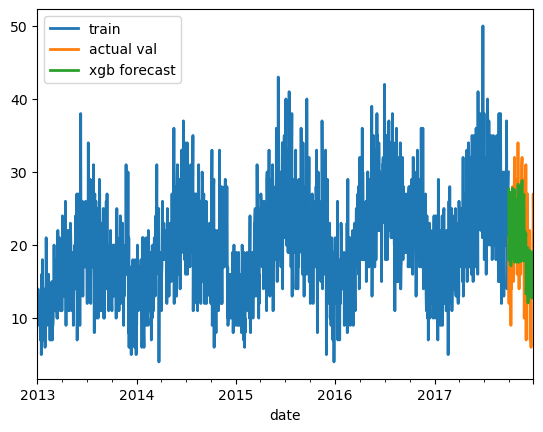

MAPE: 23.149762216327762


In [24]:
def make_date_features(ts: TimeSeries) -> TimeSeries:
    df = ts.to_dataframe().reset_index()
    date_col = df.columns[0]

    df[date_col] = pd.to_datetime(df[date_col])
    df["dayofweek"] = df[date_col].dt.dayofweek
    df["quarter"] = df[date_col].dt.quarter
    df["year"] = df[date_col].dt.year
    df["dayofyear"] = df[date_col].dt.dayofyear

    df["sin_day"] = np.sin(2 * np.pi * df["dayofyear"] / 365.25)
    df["cos_day"] = np.cos(2 * np.pi * df["dayofyear"] / 365.25)

    return TimeSeries.from_dataframe(
        df,
        time_col=date_col,
        value_cols=["dayofweek", "quarter", "year", "dayofyear", "sin_day", "cos_day"],
        fill_missing_dates=True,
        freq="D"
    )

scaler_y = Scaler()
train_scaled = scaler_y.fit_transform(train)
val_scaled = scaler_y.transform(val)

full_series = train.append(val)
full_cov = make_date_features(full_series)

train_cov = full_cov.slice_intersect(train)
val_cov = full_cov.slice_intersect(val)

model = XGBModel(
    lags=[-1, -2, -3, -7, -14],
    lags_future_covariates=[0],
    output_chunk_length=1,
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(
    train_scaled,
    future_covariates=train_cov
)

forecast_scaled = model.predict(
    n=len(val),
    future_covariates=full_cov
)

forecast = scaler_y.inverse_transform(forecast_scaled)

train.plot(label="train")
val.plot(label="actual val")
forecast.plot(label="xgb forecast")
plt.legend()
plt.show()

print("MAPE:", mape(val, forecast))

Модель на основі XGBoost значно краще прогнозує порівняно з наївними піходами, демонструє помірну точність (МАРЕ 23%).

11. Натренуйте модель ExponentialSmoothing та зробіть висновок про її якість.

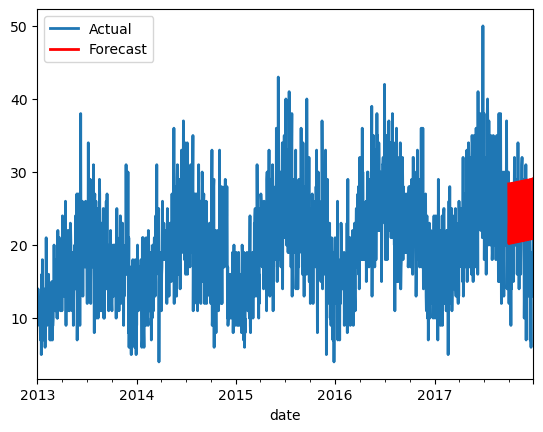

model ExponentialSmoothing() obtains MAPE: 39.01%


In [25]:
def plot_results(series, forecast):
  # Візуалізація результатів
  series.plot(label='Actual')
  forecast.plot(label='Forecast', color='red')
  plt.legend()
  plt.show()

def eval_forecast(model, val, forecast):
    mape_ = mape(val, forecast)
    print(f"model {model} obtains MAPE: {mape_:.2f}%")
    return mape_

def fit_and_plot(model, series, train, val):
  model.fit(train)

  forecast = model.predict(len(val))
  plot_results(series, forecast)
  eval_forecast(model, val, forecast)

model = ExponentialSmoothing()
fit_and_plot(model, series, train, val)

ExponentialSmoothing (MAPE 39%) прогнозує краще за наївні моделі, проте програє XGBoost на даних з трендом і сезонністю.


12. Натренуйте модель ARIMA, параметри оберіть самостійно.Зробіть висновок про її якість.

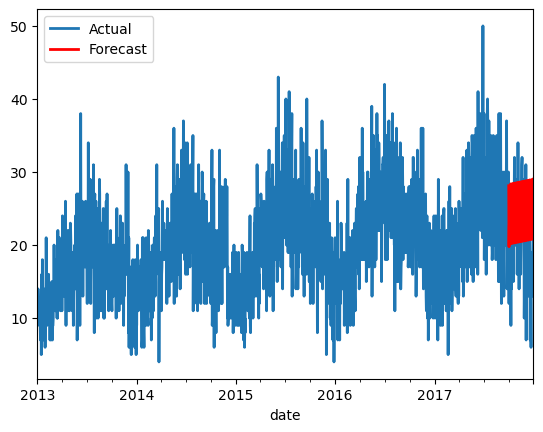

model ARIMA(p=3, q=1, seasonal_order=(1, 1, 1, 7)) obtains MAPE: 38.76%


In [26]:
# Побудова та тренування моделі ARIMA
model = ARIMA(p=3,
    d=1,
    q=1,
    seasonal_order=(1, 1, 1, 7))
fit_and_plot(model, series, train, val)

ARIMA (MAPE 38.76) трохи краще ExponentialSmoothing (39.01%), проте точність прогнозу все ще гірша ніж XGBoost.

13. Знайдіть оптимальні параметри моделі ARIMA з допомогою AutoARIMA моделі. Виконайте пошук параметрів, виведіть, які паарметри виявились оптимальними і обчисліть якість моделі. Чи поліпшилась якість порівняно з попереднім експериментом?

fitted model:
(7, 1, 0, 0, 1, 1, 0)


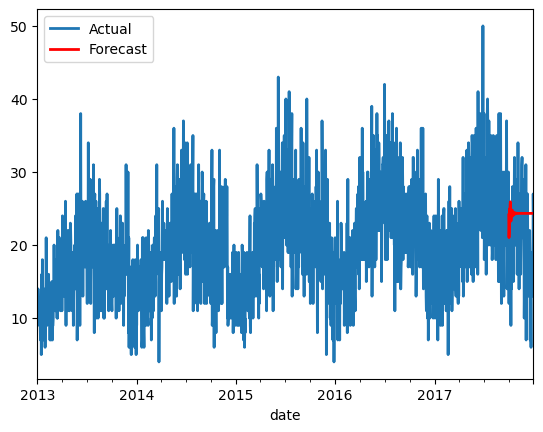

model AutoARIMA(start_p=5, max_p=12, start_q=1) obtains MAPE: 39.75%


In [27]:
from darts.models import AutoARIMA

def fit_and_plot(model, series, train, val):
  model.fit(train)
  fitted_model = model.model
  print('fitted model:')
  print(fitted_model.model_.get("arma"))
  forecast = model.predict(len(val))
  plot_results(series, forecast)
  eval_forecast(model, val, forecast)

model = AutoARIMA(start_p=5, max_p=12, start_q=1)
fit_and_plot(model, series, train, val)

Оптимальними виявились параметри ARIMA(7, 1, 1), тобто модель знайшла залежність по 7 попередніх лагах. Якість моделі не покращилась (МАРЕ 39,75%)

14. Натренуйте модель Prophet та зробіть висновок про її якість.

22:42:58 - cmdstanpy - INFO - Chain [1] start processing
22:42:58 - cmdstanpy - INFO - Chain [1] done processing


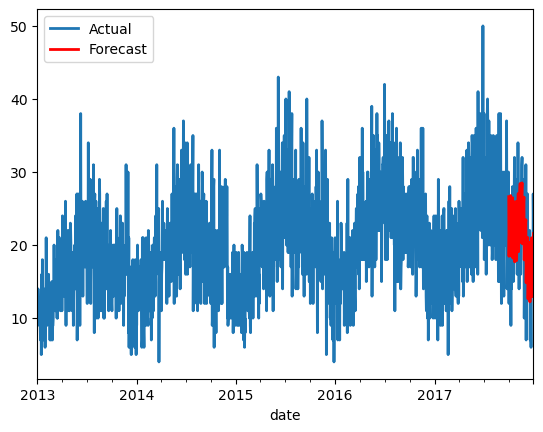

model Prophet() obtains MAPE: 23.78%


np.float64(23.778014902809723)

In [29]:
# Побудова та тренування моделі Prophet
model = Prophet()
model.fit(train)

# Прогнозування
forecast = model.predict(len(val))

# Візуалізація результатів
series.plot(label='Actual')
forecast.plot(label='Forecast', color='red')
plt.legend()
plt.show()

eval_forecast(model, val, forecast)

Модель значно точніша (MAPE 23.78%) за моделі ARIMA, проте все ще не така точна як XGBoost.

15. Натренуйте модель `RNNModel` та зробіть висновок про її якість.

In [32]:
from darts.models import RNNModel

train_rnn = train.astype(np.float32)
val_rnn = val.astype(np.float32)
series_rnn = series.astype(np.float32)

# Побудова та тренування моделі LSTM
model = RNNModel(model='LSTM', input_chunk_length=12, n_epochs=300)
model.fit(train_rnn)

# Прогнозування
forecast = model.predict(len(val_rnn))

# Візуалізація результатів
series_rnn.plot(label='Actual')
forecast.plot(label='Forecast', color='red')
plt.legend()
plt.show()

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 2.8 K  | train
6 | V               | Linear           | 26     | train
-------------------------------------------------------------
2.8 K     Trainable params
0         Non-trainable params
2.8 K     Total params
0.011     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode
/Users/oleh/miniconda3/envs/ml-2/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(tr

Epoch 299:  93%|█████████▎| 50/54 [00:00<00:00, 165.82it/s, train_loss=23.80]

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | eval 
1 | train_criterion | MSELoss          | 0      | eval 
2 | val_criterion   | MSELoss          | 0      | eval 
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 2.9 K  | train
6 | V               | Linear           | 21     | train
-------------------------------------------------------------
2.9 K     Trainable params
0         Non-trainable params
2.9 K     Total params
0.012     Total estimated model params size (MB)
4         Modules in train mode
3         Modules in eval mode


Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

/Users/oleh/miniconda3/envs/ml-2/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/oleh/miniconda3/envs/ml-2/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch 0: 100%|██████████| 108/108 [00:02<00:00, 50.22it/s, train_loss=0.0118]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████| 108/108 [00:00<00:00, 131.87it/s, train_loss=0.0193, val_loss=0.0149]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████| 108/108 [00:00<00:00, 135.84it/s, train_loss=0.0159, val_loss=0.0147] 
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 3: 100%|██████████| 108/108 [00:00<00:00, 133.99it/s, train_loss=0.00928, val_loss=0.0147]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 4: 100%|██████████| 108/108 [00:00<00:00, 133.70it/s, train_loss=0.00976, val_loss=0.0149]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 5: 100%|██████████| 108/108 [00:00<00:00, 129.75it/s, train_loss=0.014, val_loss=0.0152]  
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 6: 100%|██████████| 108/108 [00:00<00:00, 131.27it/s, train_loss=0.0115, val_loss=0.0155] 
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 7: 100%|█████

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 108/108 [00:00<00:00, 120.77it/s, train_loss=0.0114, val_loss=0.0169]


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00,  1.28it/s]


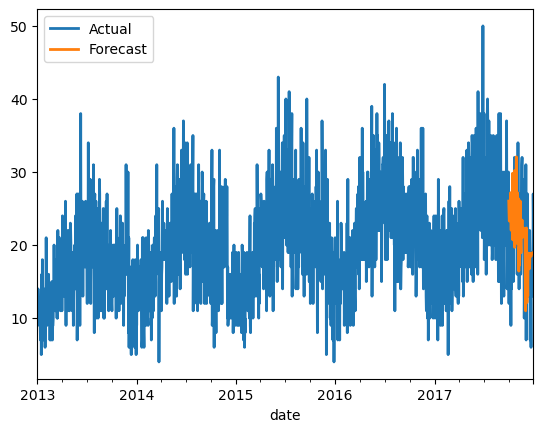

model RNNModel(model=LSTM, hidden_dim=20, training_length=20, input_chunk_length=14, batch_size=16, n_epochs=100, optimizer_kwargs={'lr': 0.001}, random_state=42, force_reset=True) obtains MAPE: 29.93%


np.float64(29.927740247760692)

In [39]:
from darts.models import RNNModel
from darts.dataprocessing.transformers import Scaler
from darts.utils.timeseries_generation import datetime_attribute_timeseries

# один scaler
scaler = Scaler()

# масштабування
train_transformed = scaler.fit_transform(train.astype(np.float32))
val_transformed = scaler.transform(val.astype(np.float32))
series_transformed = scaler.transform(series.astype(np.float32))

# covariates на реальному часовому індексі
year_series = datetime_attribute_timeseries(
    series.astype(np.float32),
    attribute="year",
    one_hot=False,
)
year_series = Scaler().fit_transform(year_series)

month_series = datetime_attribute_timeseries(
    series.astype(np.float32),
    attribute="month",
    one_hot=True,
)

covariates = year_series.stack(month_series)
covariates = covariates.astype(np.float32)

# розбиваємо covariates так само, як target
cov_train, cov_val = covariates.split_before(pd.Timestamp("2017-10-01"))

# модель
model = RNNModel(
    model="LSTM",
    input_chunk_length=14,
    training_length=20,
    hidden_dim=20,
    dropout=0.0,
    batch_size=16,
    n_epochs=100,
    optimizer_kwargs={"lr": 1e-3},
    random_state=42,
    force_reset=True,
)

# fit
model.fit(
    train_transformed,
    future_covariates=cov_train,
    val_series=val_transformed,
    val_future_covariates=cov_val,
    verbose=True,
)

# predict
forecast_transformed = model.predict(
    len(val),
    future_covariates=covariates,
)

# назад у початковий масштаб
forecast = scaler.inverse_transform(forecast_transformed)

# графік
series.plot(label="Actual")
forecast.plot(label="Forecast")
plt.legend()
plt.show()

eval_forecast(model, val, forecast)

In [40]:
eval_forecast(model, val_rnn, forecast)

model RNNModel(model=LSTM, hidden_dim=20, training_length=20, input_chunk_length=14, batch_size=16, n_epochs=100, optimizer_kwargs={'lr': 0.001}, random_state=42, force_reset=True) obtains MAPE: 29.93%


np.float32(29.927736)

RNNModel виявила кращу точність ніж наївні моделі, проте не досягла рівня Prophet та XGBoost, LSTM або немає достатньо даних, або поточна конфігурація для неї невдала.

16. Виконайте бектест для тої моделі, яка виявилась найкращою у вашому дослідженні на періоді 1 рік з передбаченнями на 1 місяць щоразу. Візуалізуйте як поводилась модель протягом бектесту, яка була точність?

In [51]:
model = XGBModel(
    lags=[-1, -2, -3, -7, -14],
    output_chunk_length=1,
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# backtest
backtest_forecasts = model.historical_forecasts(
    series,
    start=0.8,
    forecast_horizon=30,
    stride=30,
    retrain=True,
    verbose=False,
    last_points_only=False
)

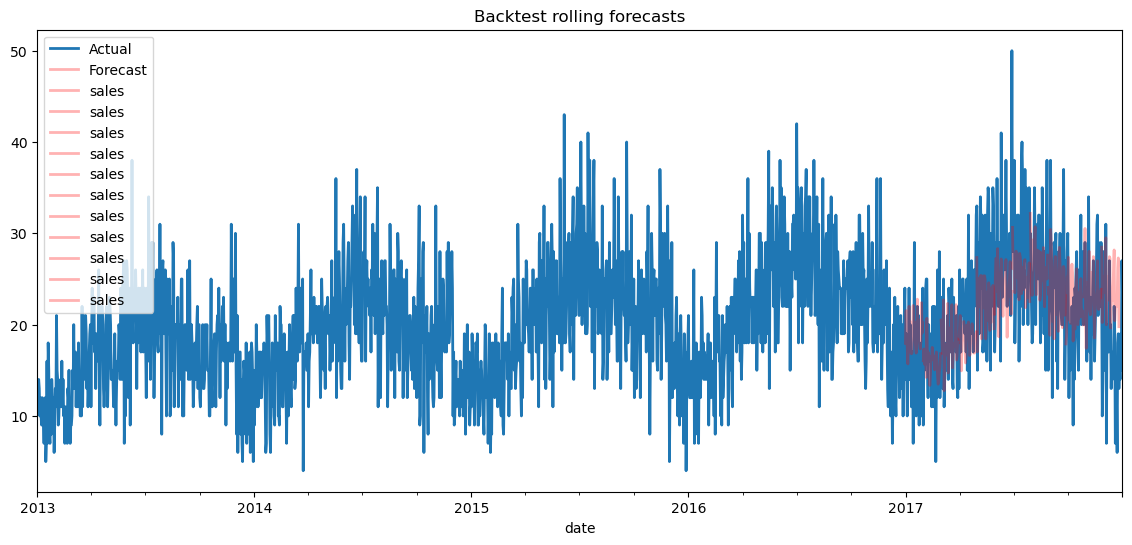

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

series.plot(label="Actual")

for i, fc in enumerate(backtest_forecasts):
    fc.plot(color="red", alpha=0.3, label="Forecast" if i==0 else "")

plt.legend()
plt.title("Backtest rolling forecasts")
plt.show()

In [53]:
from darts.metrics import mape

errors = []
for fc in backtest_forecasts:
    actual = series.slice_intersect(fc)
    errors.append(mape(actual, fc))

print(f"Mean MAPE: {sum(errors)/len(errors):.2f}%")

Mean MAPE: 25.01%


Всю варіантивність не вгадали, але виглядає непогано!

17. На цьому етапі ви зрозуміли, як моделювати продажі одного айтему з 1 магазину. Як би ви підійшли до задачі прогнозування продажів в наступному місяці для кожного з 50 айтемів в кожному з 10 магазинів? Опишіть загальний підхід
- яку модель ви б використали
- скільки моделей ви б тренували
- обгрунтуйте свій вибір.

- Я б використав модель XGBModel для прогнозування продажів кожного айтему в кожному магазині.
- Я б тренував одну модель
- Одна глобальна модель краще враховує специфіку всіх айтемів і магазинів, а також може використовувати інформацію про всі айтеми і магазини для покращення прогнозів.